<a href="https://colab.research.google.com/github/pprieri/ml/blob/main/MNIST_(Handwritten_digits)_DDMLP_%2B_Conv2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### This Notebook is part of Kaggle's MNIST Handwritten digits competition.

### I applied a simple Deep Dumb MLP and also a Conv2D NN.


Competition Description
MNIST ("Modified National Institute of Standards and Technology") is the de facto “hello world” dataset of computer vision. Since its release in 1999, this classic dataset of handwritten images has served as the basis for benchmarking classification algorithms. As new machine learning techniques emerge, MNIST remains a reliable resource for researchers and learners alike.

In this competition, your goal is to correctly identify digits from a dataset of tens of thousands of handwritten images. We’ve curated a set of tutorial-style kernels which cover everything from regression to neural networks. We encourage you to experiment with different algorithms to learn first-hand what works well and how techniques compare.

More info can be found here: https://www.kaggle.com/c/digit-recognizer/overview

### Download data

In [90]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  
# Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 67 bytes


In [91]:
!kaggle competitions download -c digit-recognizer

test.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
sample_submission.csv: Skipping, found more recently modified local copy (use --force to force download)
train.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


### Set-up

In [92]:
import tensorflow as tf
import tensorflow.keras as keras
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from os import path, getcwd, chdir

In [93]:
!unzip train.csv.zip
!unzip test.csv.zip

Archive:  train.csv.zip
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train.csv               
Archive:  test.csv.zip
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: test.csv                


In [94]:
df_train_full = pd.read_csv('train.csv',header=0,sep=',')

print(df_train_full.shape)
df_train_full.head(3)

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,...,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [95]:
df_test = pd.read_csv('test.csv',header=0,sep=',')
print(df_test.shape)
df_test.head(3)

(28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [96]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

df_train_full = reduce_mem_usage(df_train_full)
df_test = reduce_mem_usage(df_test)

Memory usage after optimization is: 58.32 MB
Decreased by 76.8%
Memory usage after optimization is: 38.59 MB
Decreased by 77.0%


In [198]:
print('\nX_test shape and dtypes \n ')
X_test = df_test

print(X_test.shape,'\n')
print(X_test.dtypes)


X_test shape and dtypes 
 
(28000, 784) 

pixel0      int8
pixel1      int8
pixel2      int8
pixel3      int8
pixel4      int8
            ... 
pixel779    int8
pixel780    int8
pixel781    int8
pixel782    int8
pixel783    int8
Length: 784, dtype: object


In [146]:
df_train = df_train_full.sample(frac=0.7, random_state=0)
df_valid = df_train_full.drop(df_train.index)

In [147]:
X_train, X_valid = df_train.drop('label',axis=1), df_valid.drop('label',axis=1)

y_train, y_valid = df_train['label'], df_valid['label']

print(f'X_train shape: {X_train.shape}, X_valid shape: {X_valid.shape}')

X_train shape: (29400, 784), X_valid shape: (12600, 784)


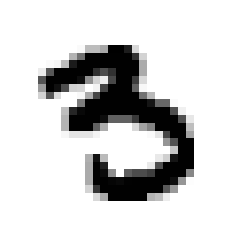

In [139]:
some_digit = X_train.values[0]
some_digit_image = some_digit.reshape(28,28)

plt.imshow(some_digit_image, cmap='binary')
plt.axis('off')
plt.show()

Feature creation and standarization



In [140]:
X_train, X_valid, X_test = X_train / 255.0, X_valid / 255.0, X_test / 255.0

Simple Sequential NN model

Epoch 1/25
1838/1838 - 9s - loss: 0.3595 - accuracy: 0.8891 - val_loss: 0.1674 - val_accuracy: 0.9496
Epoch 2/25
1838/1838 - 8s - loss: 0.2245 - accuracy: 0.9307 - val_loss: 0.1382 - val_accuracy: 0.9579
Epoch 3/25
1838/1838 - 8s - loss: 0.1827 - accuracy: 0.9427 - val_loss: 0.1243 - val_accuracy: 0.9623
Epoch 4/25
1838/1838 - 8s - loss: 0.1603 - accuracy: 0.9507 - val_loss: 0.1194 - val_accuracy: 0.9640
Epoch 5/25
1838/1838 - 8s - loss: 0.1446 - accuracy: 0.9547 - val_loss: 0.1014 - val_accuracy: 0.9692
Epoch 6/25
1838/1838 - 8s - loss: 0.1313 - accuracy: 0.9590 - val_loss: 0.1026 - val_accuracy: 0.9702
Epoch 7/25
1838/1838 - 8s - loss: 0.1138 - accuracy: 0.9639 - val_loss: 0.1001 - val_accuracy: 0.9715
Epoch 8/25
1838/1838 - 8s - loss: 0.1163 - accuracy: 0.9624 - val_loss: 0.0926 - val_accuracy: 0.9725
Epoch 9/25
1838/1838 - 8s - loss: 0.1035 - accuracy: 0.9664 - val_loss: 0.0993 - val_accuracy: 0.9716
Epoch 10/25
1838/1838 - 8s - loss: 0.0977 - accuracy: 0.9679 - val_loss: 0.0925 - 

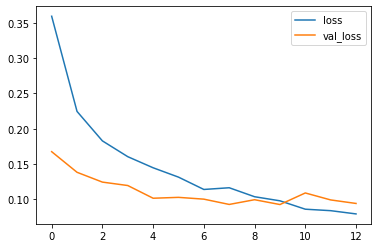

In [103]:
input_dim = X_train.shape[1]
nb_classes = len(y_train.unique())

model = keras.models.Sequential([
                                 keras.layers.Dense(300, activation='relu',input_dim=input_dim),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Dense(100, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Dense(nb_classes, activation='softmax'),
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

history = model.fit(X_train,y_train,
          epochs=25,validation_data=(X_valid,y_valid),
          batch_size=16,
          callbacks=[early_stopping],
          verbose=2)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();
print("Minimum validation loss: {}".format(history_df['val_loss'].min()))

In [104]:
preds = np.argmax(model.predict(X_test), axis=-1)

submission = pd.DataFrame({"ImageID":list(range(1,len(preds)+1)),"Label":preds}).to_csv('keras-DDMLP.csv',index=False,header=True)

## Convolutional NN

In [148]:
X_train = X_train.values.reshape(X_train.shape[0], 28, 28, 1)
X_valid = X_valid.values.reshape(X_valid.shape[0], 28, 28, 1)
X_test = X_test.values.reshape(X_test.shape[0], 28, 28, 1)

In [177]:
X_valid.shape

(12600, 28, 28, 1)

In [178]:
from keras.preprocessing.image import ImageDataGenerator

batch_size=32
# Data Augmentation doesn't help improve
# gen = ImageDataGenerator(rotation_range=8, width_shift_range=0.08, shear_range=0.3,
#                                height_shift_range=0.08, zoom_range=0.08, fill_mode='nearest')

gen = ImageDataGenerator()

batches = gen.flow(X_train, y_train, batch_size=batch_size)
val_batches = gen.flow(X_valid, y_valid, batch_size=batch_size)

steps_train = int(X_train.shape[0]/batch_size)
steps_valid = int(X_valid.shape[0]/batch_size)

Epoch 1/25
918/918 - 23s - loss: 0.4251 - accuracy: 0.8644 - val_loss: 0.1265 - val_accuracy: 0.9623
Epoch 2/25
918/918 - 22s - loss: 0.1798 - accuracy: 0.9432 - val_loss: 0.0854 - val_accuracy: 0.9734
Epoch 3/25
918/918 - 22s - loss: 0.1372 - accuracy: 0.9579 - val_loss: 0.0813 - val_accuracy: 0.9761
Epoch 4/25
918/918 - 22s - loss: 0.1232 - accuracy: 0.9612 - val_loss: 0.0650 - val_accuracy: 0.9804
Epoch 5/25
918/918 - 22s - loss: 0.1118 - accuracy: 0.9657 - val_loss: 0.0643 - val_accuracy: 0.9807
Epoch 6/25
918/918 - 22s - loss: 0.1013 - accuracy: 0.9679 - val_loss: 0.0753 - val_accuracy: 0.9778
Epoch 7/25
918/918 - 22s - loss: 0.0886 - accuracy: 0.9711 - val_loss: 0.0571 - val_accuracy: 0.9836
Epoch 8/25
918/918 - 22s - loss: 0.0866 - accuracy: 0.9723 - val_loss: 0.0576 - val_accuracy: 0.9830
Epoch 9/25
918/918 - 22s - loss: 0.0747 - accuracy: 0.9778 - val_loss: 0.0608 - val_accuracy: 0.9827
Epoch 10/25
918/918 - 22s - loss: 0.0737 - accuracy: 0.9770 - val_loss: 0.0532 - val_accura

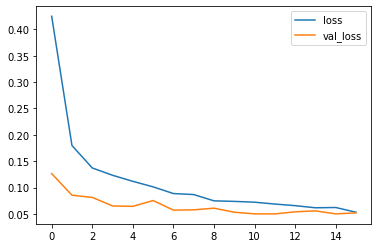

In [184]:
input_dim = X_train.shape[1:]
nb_classes = len(y_train.unique())

model = keras.models.Sequential([
                                 keras.layers.Conv2D(16,(3,3),activation='relu', input_shape=input_dim),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Conv2D(32,(3,3),activation='relu'),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Conv2D(64,(3,3),activation='relu'),
                                 keras.layers.MaxPooling2D(2),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Flatten(),
                                 keras.layers.Dense(300, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),                                 
                                 keras.layers.Dense(100, activation='relu'),
                                 keras.layers.BatchNormalization(),
                                 keras.layers.Dropout(0.15),
                                 keras.layers.Dense(nb_classes, activation='softmax')])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=5, # how many epochs to wait before stopping
    restore_best_weights=True,
)

history = model.fit(batches, steps_per_epoch=steps_train,
          epochs=25,validation_data=val_batches,
          validation_steps=steps_valid,
          callbacks=[early_stopping],
          verbose=2)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();
print("Minimum validation loss: {}".format(history_df['val_loss'].min()))

In [174]:
preds = np.argmax(model.predict(X_test), axis=-1)

submission = pd.DataFrame({"ImageID":list(range(1,len(preds)+1)),"Label":preds}).to_csv('keras-Conv2D.csv',index=False,header=True)

Score: 0.98689 accuracy on Test

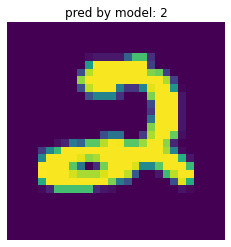

In [196]:
## Example pred

mini_pred = np.argmax(model.predict(X_test[0].reshape(1,28,28,1)),axis=-1)

plt.imshow(X_test[0].reshape(28,28))
plt.title(f'pred by model: {mini_pred[0]}')
plt.axis('off')
plt.show()